In [ ]:
import pandas as pd #importing pandas as pd
import numpy as np #importing numpy as np

df = pd.read_csv("f1_raw_merged_master.csv", na_values="\\N", low_memory=False) #reading the csv file into a dataframe
df.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,driverStandingsId,points_driver_standing,position_driver_standing,positionText_driver_standing,wins,constructorStandingsId,points_team_standing,position_team_standing,positionText_team_standing,wins_team_standing
0,1,18,1,1,22.0,1,1.0,1,1,10.0,...,1.0,10.0,1.0,1,1.0,1.0,14.0,1.0,1,1.0
1,2,18,2,2,3.0,5,2.0,2,2,8.0,...,2.0,8.0,2.0,2,0.0,2.0,8.0,3.0,3,0.0
2,3,18,3,3,7.0,7,3.0,3,3,6.0,...,3.0,6.0,3.0,3,0.0,3.0,9.0,2.0,2,0.0
3,4,18,4,4,5.0,11,4.0,4,4,5.0,...,4.0,5.0,4.0,4,0.0,4.0,5.0,4.0,4,0.0
4,5,18,5,1,23.0,3,5.0,5,5,4.0,...,5.0,4.0,5.0,5,0.0,1.0,14.0,1.0,1,1.0


In [ ]:
df_original = df.copy(deep=True)
print("Raw shape:", df_original.shape)

Raw shape: (26759, 72)


In [ ]:
df_check = df_original.copy(deep=True)

In [ ]:
print(df.shape)
print(df.head())
print(df_original.dtypes.value_counts())

(26759, 72)
   resultId  raceId  driverId  constructorId  number  grid  position  \
0         1      18         1              1    22.0     1       1.0   
1         2      18         2              2     3.0     5       2.0   
2         3      18         3              3     7.0     7       3.0   
3         4      18         4              4     5.0    11       4.0   
4         5      18         5              1    23.0     3       5.0   

  positionText  positionOrder  points  ...  driverStandingsId  \
0            1              1    10.0  ...                1.0   
1            2              2     8.0  ...                2.0   
2            3              3     6.0  ...                3.0   
3            4              4     5.0  ...                4.0   
4            5              5     4.0  ...                5.0   

  points_driver_standing  position_driver_standing  \
0                   10.0                       1.0   
1                    8.0                       2.0   
2 

In [ ]:
print(df.columns[:15])
print(df.columns[-3:])
print(df.head())

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank'],
      dtype='str')
Index(['position_team_standing', 'positionText_team_standing',
       'wins_team_standing'],
      dtype='str')
   resultId  raceId  driverId  constructorId  number  grid  position  \
0         1      18         1              1    22.0     1       1.0   
1         2      18         2              2     3.0     5       2.0   
2         3      18         3              3     7.0     7       3.0   
3         4      18         4              4     5.0    11       4.0   
4         5      18         5              1    23.0     3       5.0   

  positionText  positionOrder  points  ...  driverStandingsId  \
0            1              1    10.0  ...                1.0   
1            2              2     8.0  ...                2.0   
2            3              3     6.0  ..

In [ ]:
df_original = df.copy(deep=True)

In [ ]:
print(df_original.shape)

(26759, 72)


In [ ]:
missing = df_original.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

sprint_time                     26459
sprint_date                     26399
fp3_time                        25700
fp2_time                        25400
fp1_time                        25400
quali_time                      25400
fp3_date                        25320
fp2_date                        24960
quali_date                      24960
fp1_date                        24960
q3                              23130
q2                              20912
number_driver                   20198
milliseconds                    19079
time                            19079
fastestLapTime                  18507
fastestLapSpeed                 18507
fastestLap                      18507
time_race                       18469
rank                            18249
code                            16581
q1                              16421
position_quali                  16265
number_quali                    16265
qualifyId                       16265
constructorId_quali             16265
position    

In [ ]:
print("Duplicate rows:", df_original.duplicated().sum())

Duplicate rows: 0


In [ ]:
range_cols = [
    "grid",
    "positionOrder",
    "points",
    "laps",
    "fastestLapSpeed"
]

print("\nMinimum and maximum values:")

print(
    df_original[range_cols]
    .agg(["min", "max"])
)


Minimum and maximum values:
     grid  positionOrder  points  laps  fastestLapSpeed
min     0              1     0.0     0            89.54
max    34             39    50.0   200           257.32


In [ ]:
review_cols = [
    "year",
    "name",
    "forename",
    "surname",
    "grid",
    "positionOrder",
    "points",
    "laps",
    "fastestLapSpeed"
]

review_df = df_original.copy(deep=True)
review_df["fastestLapSpeed"] = pd.to_numeric(
    review_df["fastestLapSpeed"],
    errors="coerce"
)

records_to_review = review_df.loc[
    (review_df["grid"] == 0)
    | (review_df["laps"] == 0)
    | (review_df["fastestLapSpeed"] < 120),
    review_cols
].sort_values(
    ["year", "grid", "positionOrder"]
)

print(
    records_to_review
    .head(30)
    .to_string(index=False)
)

 year               name forename        surname  grid  positionOrder  points  laps  fastestLapSpeed
 1950  Monaco Grand Prix     Nino         Farina     2             11     0.0     0              NaN
 1950  Monaco Grand Prix    Luigi        Fagioli     5             12     0.0     0              NaN
 1950   Swiss Grand Prix     Yves      Cabantous     7             18     0.0     0              NaN
 1950  Monaco Grand Prix    Louis         Rosier    10             13     0.0     0              NaN
 1950  Monaco Grand Prix   Robert         Manzon    11             14     0.0     0              NaN
 1950  Monaco Grand Prix    Toulo de Graffenried    12             15     0.0     0              NaN
 1950  Monaco Grand Prix  Maurice    Trintignant    13             16     0.0     0              NaN
 1950  Monaco Grand Prix     Cuth       Harrison    14             17     0.0     0              NaN
 1950  Monaco Grand Prix   Franco            Rol    17             18     0.0     0        

In [ ]:
records_to_review = records_to_review.copy()

records_to_review["grid_for_gain"] = (
    records_to_review["grid"]
    .replace(0, pd.NA)
)

records_to_review["positions_gained"] = (
    records_to_review["grid_for_gain"]
    - records_to_review["positionOrder"]
)

print(
    records_to_review
    .head(30)
    .round(2)
    .to_string(index=False)
)

 year               name forename        surname  grid  positionOrder  points  laps  fastestLapSpeed grid_for_gain positions_gained
 1950  Monaco Grand Prix     Nino         Farina     2             11     0.0     0              NaN             2               -9
 1950  Monaco Grand Prix    Luigi        Fagioli     5             12     0.0     0              NaN             5               -7
 1950   Swiss Grand Prix     Yves      Cabantous     7             18     0.0     0              NaN             7              -11
 1950  Monaco Grand Prix    Louis         Rosier    10             13     0.0     0              NaN            10               -3
 1950  Monaco Grand Prix   Robert         Manzon    11             14     0.0     0              NaN            11               -3
 1950  Monaco Grand Prix    Toulo de Graffenried    12             15     0.0     0              NaN            12               -3
 1950  Monaco Grand Prix  Maurice    Trintignant    13             16     0.

In [ ]:
def lap_time_to_seconds(series):
    time_parts = (
        series.astype("string")
        .str.extract(
            r"(?:(\d+):)?(\d+(?:\.\d+)?)$"
        )
    )

    minutes = pd.to_numeric(
        time_parts[0],
        errors="coerce"
    ).fillna(0)

    seconds = pd.to_numeric(
        time_parts[1],
        errors="coerce"
    )

    total_seconds = (
        minutes * 60
        + seconds
    )

    return total_seconds.where(
        series.notna()
    )


def clean_data(data):
    # Work on a copy so the supplied DataFrame is not changed
    clean = data.copy(deep=True)

    # Convert calculation columns to numeric values
    numeric_cols = [
        "resultId",
        "raceId",
        "driverId",
        "constructorId",
        "number",
        "grid",
        "position",
        "positionOrder",
        "points",
        "laps",
        "milliseconds",
        "fastestLap",
        "rank",
        "fastestLapSpeed",
        "statusId",
        "year",
        "round",
        "circuitId",
        "lat",
        "lng",
        "alt",
        "number_driver",
        "qualifyId",
        "constructorId_quali",
        "number_quali",
        "position_quali",
        "driverStandingsId",
        "points_driver_standing",
        "position_driver_standing",
        "wins",
        "constructorStandingsId",
        "points_team_standing",
        "position_team_standing",
        "wins_team_standing"
    ]

    for col in numeric_cols:
        clean[col] = pd.to_numeric(
            clean[col],
            errors="coerce"
        )

    # Give ambiguous source columns clearer names
    clean = clean.rename(
        columns={
            "number": "car_number",
            "name": "race_name",
            "date": "race_date",
            "time": "result_time"
        }
    )

    # Convert date columns
    date_cols = [
        "race_date",
        "dob",
        "fp1_date",
        "fp2_date",
        "fp3_date",
        "quali_date",
        "sprint_date"
    ]

    for col in date_cols:
        clean[col] = pd.to_datetime(
            clean[col],
            format="mixed",
            errors="coerce"
        )

    # Identify clearly unreliable records
    invalid_record = (
        clean["resultId"].isna()
        | clean["raceId"].isna()
        | clean["driverId"].isna()
        | clean["constructorId"].isna()
        | (clean["points"] < 0)
        | (clean["laps"] < 0)
        | ~clean["positionOrder"].between(1, 40)
    )

    print(
        "Clearly unreliable records "
        "removed during cleaning:"
    )

    print(
        clean.loc[
            invalid_record,
            [
                "resultId",
                "raceId",
                "driverId",
                "constructorId",
                "points",
                "laps",
                "positionOrder"
            ]
        ].to_string(index=False)
    )

    # Remove clearly unreliable records
    clean = clean.loc[
        ~invalid_record
    ].copy()

    # Grid zero means no normal starting position
    clean["grid"] = clean["grid"].mask(
        clean["grid"].eq(0)
    )

    # Convert lap and qualifying times to seconds
    clean["fastest_lap_seconds"] = (
        lap_time_to_seconds(
            clean["fastestLapTime"]
        )
    )

    for source_col, new_col in [
        ("q1", "q1_seconds"),
        ("q2", "q2_seconds"),
        ("q3", "q3_seconds")
    ]:
        clean[new_col] = (
            lap_time_to_seconds(
                clean[source_col]
            )
        )

    # Create the driver's full name
    clean["driver_name"] = (
        clean["forename"]
        .fillna("")
        .str.strip()
        + " "
        + clean["surname"]
        .fillna("")
        .str.strip()
    ).str.strip()

    # Calculate driver age at each race
    clean["age_at_race"] = (
        (
            clean["race_date"]
            - clean["dob"]
        ).dt.days
        / 365.2425
    ).round(2)

    # Create race-performance columns
    clean["classified_finish"] = (
        clean["position"].notna()
    )

    clean["won_race"] = (
        clean["position"].eq(1)
    )

    clean["podium_finish"] = (
        clean["position"]
        .between(1, 3)
    )

    clean["points_finish"] = (
        clean["points"].gt(0)
    )

    clean["top_10_start"] = (
        clean["grid"]
        .between(1, 10)
    )

    clean["positions_gained"] = (
        clean["grid"]
        - clean["positionOrder"]
    )

    clean["starting_group"] = pd.cut(
        clean["grid"],
        bins=[
            0,
            3,
            10,
            20,
            float("inf")
        ],
        labels=[
            "Top 3",
            "4–10",
            "11–20",
            "21+"
        ]
    )

    # Remove URL fields not needed for analysis
    clean = clean.drop(
        columns=[
            "url",
            "url_circuit",
            "url_driver",
            "url_team"
        ],
        errors="ignore"
    )

    # Remove duplicate results
    clean = clean.drop_duplicates(
        subset="resultId",
        keep="first"
    )

    # Reset row numbers
    clean = clean.reset_index(
        drop=True
    )

    return clean

In [ ]:
df_clean_preview = clean_data(
    df_original
)

Clearly unreliable records removed during cleaning:
Empty DataFrame
Columns: [resultId, raceId, driverId, constructorId, points, laps, positionOrder]
Index: []


In [ ]:
print(
    "Original shape:",
    df_original.shape
)

print(
    "Cleaned shape:",
    df_clean_preview.shape
)

print(
    "Rows removed:",
    len(df_original)
    - len(df_clean_preview)
)

Original shape: (26759, 72)
Cleaned shape: (26759, 81)
Rows removed: 0


In [ ]:
performance_cols = [
    "year",
    "grid",
    "positionOrder",
    "points",
    "laps",
    "fastestLapSpeed",
    "age_at_race",
    "positions_gained"
]

print(
    "\nCleaned performance ranges:"
)

print(
    df_clean_preview[
        performance_cols
    ].agg(["min", "max"])
)


Cleaned performance ranges:
     year  grid  positionOrder  points  laps  fastestLapSpeed  age_at_race  \
min  1950   1.0              1     0.0     0            89.54        17.45   
max  2024  34.0             39    50.0   200           257.32        58.79   

     positions_gained  
min             -31.0  
max              30.0  


In [ ]:
print(
    "\nGrid positions below 1:",
    (
        df_clean_preview["grid"]
        < 1
    ).sum()
)

print(
    "Negative points:",
    (
        df_clean_preview["points"]
        < 0
    ).sum()
)

print(
    "Negative lap counts:",
    (
        df_clean_preview["laps"]
        < 0
    ).sum()
)

print(
    "Finishing orders outside 1 to 40:",
    (
        ~df_clean_preview[
            "positionOrder"
        ].between(1, 40)
    ).sum()
)


Grid positions below 1: 0
Negative points: 0
Negative lap counts: 0
Finishing orders outside 1 to 40: 0


In [ ]:
missing = (
    df_clean_preview
    .isna()
    .sum()
)

print(
    "\nColumns still containing "
    "missing values:"
)

print(
    missing[missing > 0]
    .sort_values(ascending=False)
)

print(
    "\nDuplicate result IDs:",
    df_clean_preview[
        "resultId"
    ].duplicated().sum()
)


Columns still containing missing values:
sprint_time                     26459
sprint_date                     26399
fp3_time                        25700
fp2_time                        25400
fp1_time                        25400
quali_time                      25400
fp3_date                        25320
fp1_date                        24960
quali_date                      24960
fp2_date                        24960
q3                              23130
q3_seconds                      23130
q2                              20912
q2_seconds                      20912
number_driver                   20198
milliseconds                    19079
result_time                     19079
fastest_lap_seconds             18507
fastestLap                      18507
fastestLapSpeed                 18507
fastestLapTime                  18507
time_race                       18469
rank                            18249
code                            16581
q1_seconds                      16421
q1      

In [ ]:
print(
    "\nSource URL column still present:",
    "url" in df_clean_preview.columns
)

print(
    "Driver-name column present:",
    "driver_name"
    in df_clean_preview.columns
)

print(
    "Podium column present:",
    "podium_finish"
    in df_clean_preview.columns
)

print(
    "Positions-gained column present:",
    "positions_gained"
    in df_clean_preview.columns
)


Source URL column still present: False
Driver-name column present: True
Podium column present: True
Positions-gained column present: True


In [ ]:
print(
    "\nFirst five cleaned records:"
)

print(
    df_clean_preview[
        [
            "year",
            "race_name",
            "driver_name",
            "name_team",
            "grid",
            "positionOrder",
            "points",
            "podium_finish",
            "positions_gained"
        ]
    ].head()
)


First five cleaned records:
   year              race_name        driver_name   name_team  grid  \
0  2008  Australian Grand Prix     Lewis Hamilton     McLaren   1.0   
1  2008  Australian Grand Prix      Nick Heidfeld  BMW Sauber   5.0   
2  2008  Australian Grand Prix       Nico Rosberg    Williams   7.0   
3  2008  Australian Grand Prix    Fernando Alonso     Renault  11.0   
4  2008  Australian Grand Prix  Heikki Kovalainen     McLaren   3.0   

   positionOrder  points  podium_finish  positions_gained  
0              1    10.0           True               0.0  
1              2     8.0           True               3.0  
2              3     6.0           True               4.0  
3              4     5.0          False               7.0  
4              5     4.0          False              -2.0  


In [ ]:
print(
    "Original data shape:",
    df_original.shape
)

Original data shape: (26759, 72)


In [ ]:
import sqlite3

In [ ]:
df_etl_clean = (
    df_clean_preview
    .copy(deep=True)
)

with sqlite3.connect(
    "f1_etl.db"
) as conn:
    df_etl_clean.to_sql(
        "clean",
        conn,
        if_exists="replace",
        index=False
    )

print("ETL completed.")

print(
    "Cleaned table shape:",
    df_etl_clean.shape
)

ETL completed.
Cleaned table shape: (26759, 81)


In [ ]:
df_etl_clean.to_csv(
    "f1_cleaned_24257694.csv",
    index=False
)

print("Cleaned CSV saved successfully.")

Cleaned CSV saved successfully.


In [ ]:
print(
    "ETL transforms before "
    "loading the data."
)

ETL transforms before loading the data.


In [ ]:
with sqlite3.connect(
    "f1_elt.db"
) as conn:

    # Load the untouched raw data first
    df_original.to_sql(
        "raw",
        conn,
        if_exists="replace",
        index=False
    )

    # Read the raw table back into Pandas
    df_elt_raw = pd.read_sql(
        "SELECT * FROM raw",
        conn
    )

    # Transform after loading
    df_elt_clean = clean_data(
        df_elt_raw
    )

    # Store the cleaned result
    df_elt_clean.to_sql(
        "clean",
        conn,
        if_exists="replace",
        index=False
    )

Clearly unreliable records removed during cleaning:
Empty DataFrame
Columns: [resultId, raceId, driverId, constructorId, points, laps, positionOrder]
Index: []


In [ ]:
print("ELT completed.")

print(
    "Raw table shape:",
    df_elt_raw.shape
)

print(
    "Cleaned table shape:",
    df_elt_clean.shape
)

ELT completed.
Raw table shape: (26759, 72)
Cleaned table shape: (26759, 81)


In [ ]:
print(
    "ELT loads the raw data "
    "before transforming it."
)

ELT loads the raw data before transforming it.


In [ ]:
with sqlite3.connect(
    "f1_etl.db"
) as conn:
    etl_tables = pd.read_sql(
        (
            "SELECT name "
            "FROM sqlite_master "
            "WHERE type='table'"
        ),
        conn
    )

print("Tables in f1_etl.db:")
print(etl_tables)

with sqlite3.connect(
    "f1_elt.db"
) as conn:
    elt_tables = pd.read_sql(
        (
            "SELECT name "
            "FROM sqlite_master "
            "WHERE type='table'"
        ),
        conn
    )

print("\nTables in f1_elt.db:")
print(elt_tables)

Tables in f1_etl.db:
    name
0  clean

Tables in f1_elt.db:
    name
0    raw
1  clean


In [ ]:
print(
    df_etl_clean[
        "points"
    ].mean()
)

print(
    df_etl_clean[
        ["points", "laps"]
    ].mean()
)

1.9876321985126502
points     1.987632
laps      46.301768
dtype: float64


In [ ]:
import time

# Slow method: loop
start = time.time()

slow_result = []

for i in range(
    len(df_etl_clean)
):
    slow_result.append(
        df_etl_clean[
            "fastestLapSpeed"
        ].iloc[i]
        * 0.621371
    )

slow_time = (
    time.time()
    - start
)

# Fast method: vectorised calculation
start = time.time()

fast_result = (
    df_etl_clean[
        "fastestLapSpeed"
    ]
    * 0.621371
)

fast_time = (
    time.time()
    - start
)

print("Slow result:")
print(slow_result[:5])

print("\nFast result:")
print(
    fast_result
    .head()
    .tolist()
)

print("\nSlow time:", slow_time)
print("Fast time:", fast_time)

print(
    "\nFast method is",
    slow_time / fast_time,
    "times faster"
)

Slow result:
[np.float64(135.6452893), np.float64(135.20163040600002), np.float64(134.66290174899999), np.float64(133.883081144), np.float64(135.698105835)]

Fast result:
[135.6452893, 135.20163040600002, 134.66290174899999, 133.883081144, 135.698105835]

Slow time: 1.1339225769042969
Fast time: 0.0004303455352783203

Fast method is 2634.9119113573406 times faster


In [ ]:
print(
    df_etl_clean.shape
)

print(
    df_etl_clean
    .dtypes
    .value_counts()
)

print(
    df_etl_clean.info()
)

print(
    df_etl_clean.describe()
)

(26759, 81)
str               28
float64           25
int64             11
datetime64[us]     7
bool               5
Float64            4
category           1
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 81 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   resultId                      26759 non-null  int64         
 1   raceId                        26759 non-null  int64         
 2   driverId                      26759 non-null  int64         
 3   constructorId                 26759 non-null  int64         
 4   car_number                    26753 non-null  float64       
 5   grid                          25121 non-null  float64       
 6   position                      15806 non-null  float64       
 7   positionText                  26759 non-null  str           
 8   positionOrder                 26759 non-null  int64 

In [ ]:
summary_cols = [
    "grid",
    "positionOrder",
    "points",
    "laps",
    "fastestLapSpeed",
    "age_at_race",
    "positions_gained"
]

print(
    df_etl_clean[
        summary_cols
    ].describe()
)

skew_results = (
    df_etl_clean[
        summary_cols
    ]
    .skew()
    .round(2)
)

print(skew_results)

print(
    df_etl_clean[
        "podium_finish"
    ]
    .value_counts(
        normalize=True
    )
)

print(
    "Minimum year retained:",
    df_etl_clean["year"].min()
)

print(
    "Minimum grid retained:",
    df_etl_clean["grid"].min()
)

               grid  positionOrder        points          laps  \
count  25121.000000   26759.000000  26759.000000  26759.000000   
mean      11.860834      12.794051      1.987632     46.301768   
std        6.830260       7.665951      4.351209     29.496557   
min        1.000000       1.000000      0.000000      0.000000   
25%        6.000000       6.000000      0.000000     23.000000   
50%       12.000000      12.000000      0.000000     53.000000   
75%       17.000000      18.000000      2.000000     66.000000   
max       34.000000      39.000000     50.000000    200.000000   

       fastestLapSpeed   age_at_race  positions_gained  
count      8252.000000  26759.000000      25121.000000  
mean        204.116330     29.993585          0.002189  
std          21.377265      5.268632          7.185223  
min          89.540000     17.450000        -31.000000  
25%         193.322500     26.140000         -4.000000  
50%         204.894000     29.430000          1.000000  
75%   

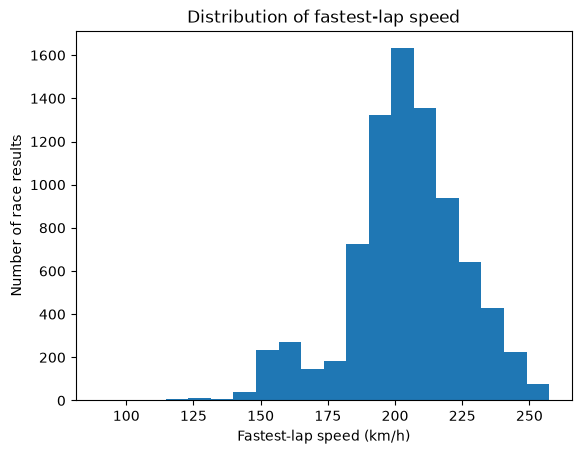

In [ ]:
import matplotlib.pyplot as plt

plt.hist(
    df_etl_clean[
        "fastestLapSpeed"
    ].dropna(),
    bins=20
)

plt.xlabel(
    "Fastest-lap speed (km/h)"
)

plt.ylabel(
    "Number of race results"
)

plt.title(
    "Distribution of fastest-lap speed"
)

plt.show()

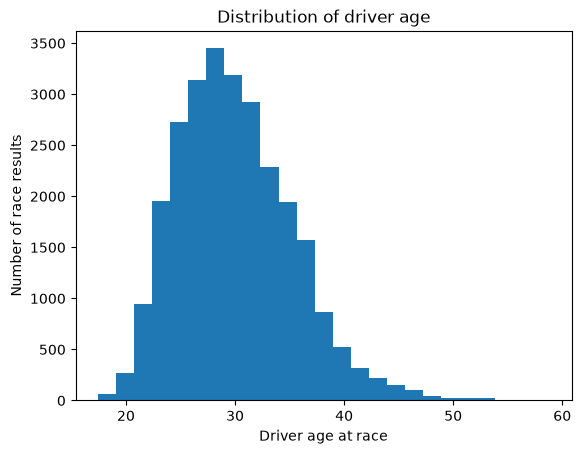

In [ ]:
plt.hist(
    df_etl_clean[
        "age_at_race"
    ].dropna(),
    bins=25
)

plt.xlabel(
    "Driver age at race"
)

plt.ylabel(
    "Number of race results"
)

plt.title(
    "Distribution of driver age"
)

plt.show()

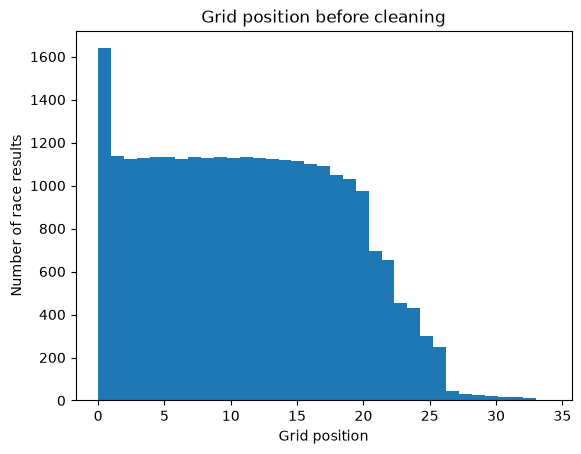

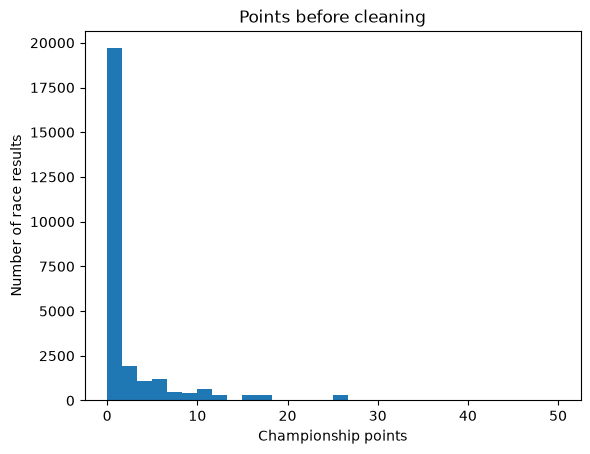

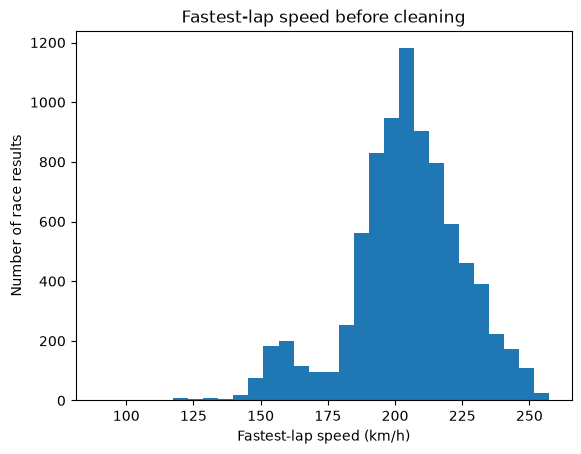

In [ ]:
plt.hist(
    df_original["grid"].dropna(),
    bins=35
)

plt.title(
    "Grid position before cleaning"
)

plt.xlabel("Grid position")
plt.ylabel("Number of race results")
plt.show()

plt.hist(
    df_original["points"].dropna(),
    bins=30
)

plt.title("Points before cleaning")
plt.xlabel("Championship points")
plt.ylabel("Number of race results")
plt.show()

plt.hist(
    df_original[
        "fastestLapSpeed"
    ].dropna(),
    bins=30
)

plt.title(
    "Fastest-lap speed before cleaning"
)

plt.xlabel(
    "Fastest-lap speed (km/h)"
)

plt.ylabel("Number of race results")
plt.show()

In [ ]:
for col in [
    "grid",
    "positionOrder",
    "points",
    "laps",
    "fastestLapSpeed"
]:
    print(
        col,
        "raw range:",
        (
            df_original[col].min(),
            df_original[col].max()
        ),
        "clean range:",
        (
            df_etl_clean[col].min(),
            df_etl_clean[col].max()
        )
    )

grid raw range: (np.int64(0), np.int64(34)) clean range: (np.float64(1.0), np.float64(34.0))
positionOrder raw range: (np.int64(1), np.int64(39)) clean range: (np.int64(1), np.int64(39))
points raw range: (np.float64(0.0), np.float64(50.0)) clean range: (np.float64(0.0), np.float64(50.0))
laps raw range: (np.int64(0), np.int64(200)) clean range: (np.int64(0), np.int64(200))
fastestLapSpeed raw range: (np.float64(89.54), np.float64(257.32)) clean range: (np.float64(89.54), np.float64(257.32))


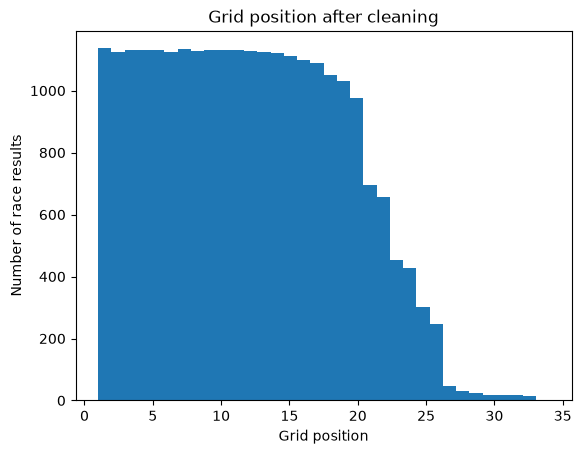

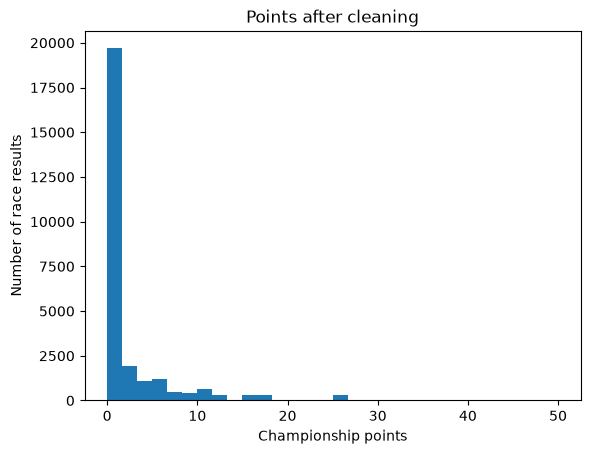

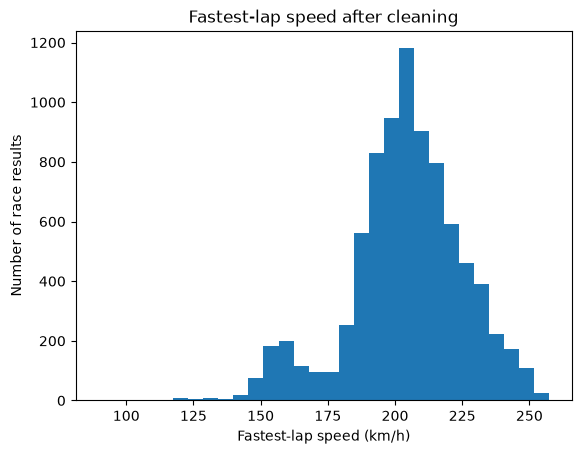

In [ ]:
plt.hist(
    df_etl_clean["grid"].dropna(),
    bins=34
)

plt.title(
    "Grid position after cleaning"
)

plt.xlabel("Grid position")
plt.ylabel("Number of race results")
plt.show()

plt.hist(
    df_etl_clean["points"].dropna(),
    bins=30
)

plt.title("Points after cleaning")
plt.xlabel("Championship points")
plt.ylabel("Number of race results")
plt.show()

plt.hist(
    df_etl_clean[
        "fastestLapSpeed"
    ].dropna(),
    bins=30
)

plt.title(
    "Fastest-lap speed after cleaning"
)

plt.xlabel(
    "Fastest-lap speed (km/h)"
)

plt.ylabel("Number of race results")
plt.show()

C:\Users\Rakesh Kalidindi\AppData\Local\Temp\ipykernel_2272\3669838335.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


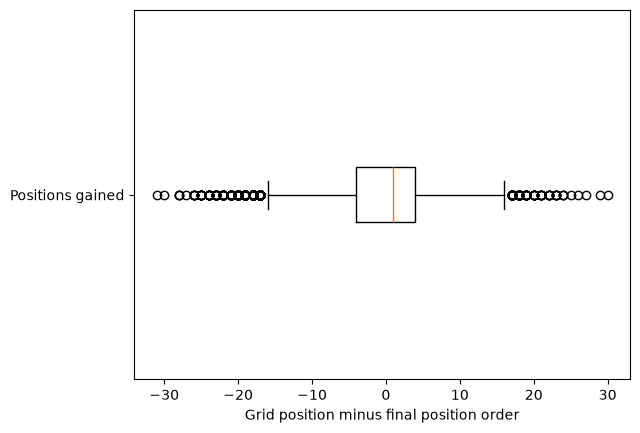

In [ ]:
plt.boxplot(
    df_etl_clean[
        "positions_gained"
    ].dropna(),
    vert=False,
    tick_labels=[
        "Positions gained"
    ]
)

plt.xlabel(
    "Grid position minus "
    "final position order"
)

plt.show()

In [ ]:
def iqr_flag(series):
    q1, q3 = series.quantile(
        [0.25, 0.75]
    )

    iqr = q3 - q1

    return (
        (
            series
            < q1 - 1.5 * iqr
        )
        |
        (
            series
            > q3 + 1.5 * iqr
        )
    )


speed_flag = iqr_flag(
    df_etl_clean[
        "fastestLapSpeed"
    ]
)

gain_flag = iqr_flag(
    df_etl_clean[
        "positions_gained"
    ]
)

age_flag = iqr_flag(
    df_etl_clean[
        "age_at_race"
    ]
)

performance_flags = (
    speed_flag
    | gain_flag
    | age_flag
)

print(
    df_etl_clean.loc[
        performance_flags,
        [
            "year",
            "race_name",
            "driver_name",
            "grid",
            "positionOrder",
            "positions_gained",
            "fastestLapSpeed",
            "age_at_race"
        ]
    ]
    .head(40)
    .to_string(index=False)
)

mean_speed = (
    df_etl_clean[
        "fastestLapSpeed"
    ].mean()
)

std_speed = (
    df_etl_clean[
        "fastestLapSpeed"
    ].std()
)

z_speed = (
    (
        df_etl_clean[
            "fastestLapSpeed"
        ]
        - mean_speed
    )
    / std_speed
)

print(
    "Fastest-lap speeds "
    "with |z| > 3:"
)

print(
    df_etl_clean.loc[
        z_speed.abs() > 3,
        [
            "year",
            "race_name",
            "driver_name",
            "fastestLapSpeed"
        ]
    ]
)

 year            race_name          driver_name  grid  positionOrder  positions_gained  fastestLapSpeed  age_at_race
 2008 Malaysian Grand Prix         Felipe Massa   1.0             19             -18.0          208.048        26.91
 2008    Monaco Grand Prix       Lewis Hamilton   3.0              1               2.0          153.152        23.38
 2008    Monaco Grand Prix        Robert Kubica   5.0              2               3.0          154.286        23.46
 2008    Monaco Grand Prix         Felipe Massa   1.0              3              -2.0          154.379        27.08
 2008    Monaco Grand Prix          Mark Webber   9.0              4               5.0          152.133        31.74
 2008    Monaco Grand Prix     Sebastian Vettel  19.0              5              14.0          152.614        20.90
 2008    Monaco Grand Prix   Rubens Barrichello  14.0              6               8.0          151.104        36.01
 2008    Monaco Grand Prix      Kazuki Nakajima  13.0           

In [ ]:
print(
    df_etl_clean.loc[
        (
            df_etl_clean["year"]
            == 2010
        )
        &
        (
            df_etl_clean["race_name"]
            == "Monaco Grand Prix"
        )
        &
        (
            df_etl_clean["driver_name"]
            == "Jenson Button"
        )
    ].to_string(index=False)
)

 resultId  raceId  driverId  constructorId  car_number  grid  position positionText  positionOrder  points  laps result_time  milliseconds  fastestLap  rank fastestLapTime  fastestLapSpeed  statusId  year  round  circuitId         race_name  race_date time_race fp1_date fp1_time fp2_date fp2_time fp3_date fp3_time quali_date quali_time sprint_date sprint_time circuitRef      name_circuit    location country     lat     lng  alt driverRef  number_driver code forename surname        dob nationality constructorRef name_team nationality_team  qualifyId  constructorId_quali  number_quali  position_quali      q1      q2      q3  driverStandingsId  points_driver_standing  position_driver_standing positionText_driver_standing  wins  constructorStandingsId  points_team_standing  position_team_standing positionText_team_standing  wins_team_standing  fastest_lap_seconds  q1_seconds  q2_seconds  q3_seconds   driver_name  age_at_race  classified_finish  won_race  podium_finish  points_finish  top_1

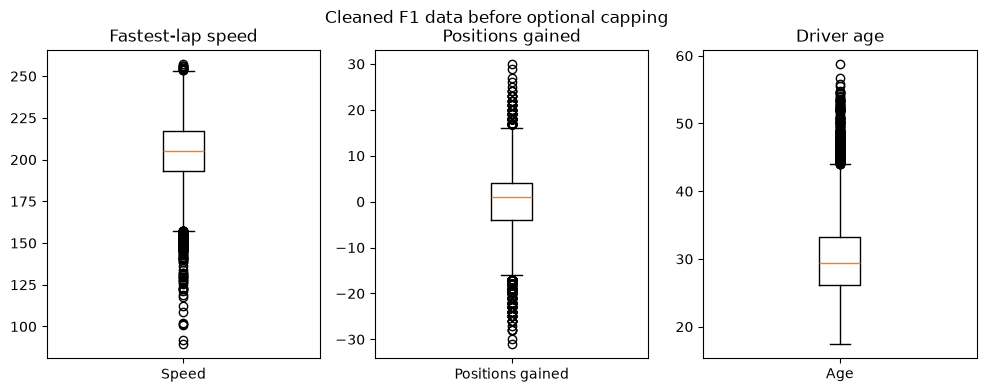

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4)
)

axes[0].boxplot(
    df_etl_clean[
        "fastestLapSpeed"
    ].dropna(),
    tick_labels=["Speed"]
)

axes[0].set_title(
    "Fastest-lap speed"
)

axes[1].boxplot(
    df_etl_clean[
        "positions_gained"
    ].dropna(),
    tick_labels=["Positions gained"]
)

axes[1].set_title(
    "Positions gained"
)

axes[2].boxplot(
    df_etl_clean[
        "age_at_race"
    ].dropna(),
    tick_labels=["Age"]
)

axes[2].set_title(
    "Driver age"
)

plt.suptitle(
    "Cleaned F1 data "
    "before optional capping"
)

plt.show()

In [ ]:
df_sensitivity = (
    df_etl_clean
    .copy(deep=True)
)

df_sensitivity[
    "speed_capped"
] = df_sensitivity[
    "fastestLapSpeed"
].clip(
    lower=df_sensitivity[
        "fastestLapSpeed"
    ].quantile(0.01),
    upper=df_sensitivity[
        "fastestLapSpeed"
    ].quantile(0.99)
)

df_sensitivity[
    "gain_capped"
] = df_sensitivity[
    "positions_gained"
].clip(
    lower=df_sensitivity[
        "positions_gained"
    ].quantile(0.01),
    upper=df_sensitivity[
        "positions_gained"
    ].quantile(0.99)
)

df_sensitivity[
    "age_capped"
] = df_sensitivity[
    "age_at_race"
].clip(
    lower=df_sensitivity[
        "age_at_race"
    ].quantile(0.01),
    upper=df_sensitivity[
        "age_at_race"
    ].quantile(0.99)
)

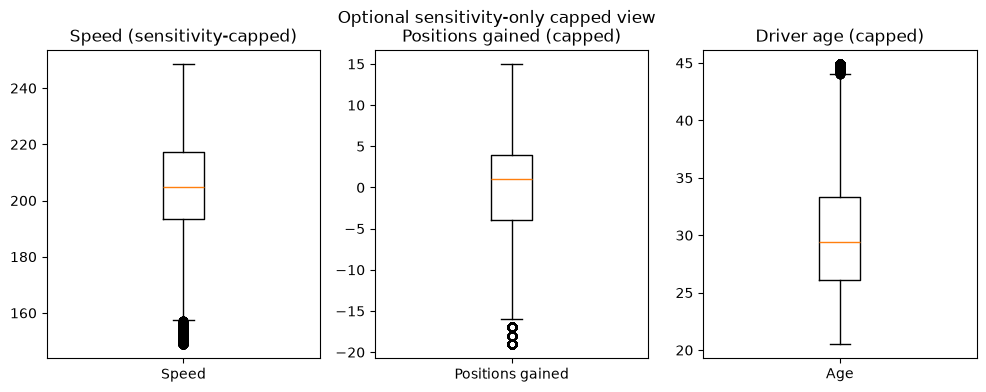

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(12, 4)
)

axes[0].boxplot(
    df_sensitivity[
        "speed_capped"
    ].dropna(),
    tick_labels=["Speed"]
)

axes[0].set_title(
    "Speed (sensitivity-capped)"
)

axes[1].boxplot(
    df_sensitivity[
        "gain_capped"
    ].dropna(),
    tick_labels=["Positions gained"]
)

axes[1].set_title(
    "Positions gained (capped)"
)

axes[2].boxplot(
    df_sensitivity[
        "age_capped"
    ].dropna(),
    tick_labels=["Age"]
)

axes[2].set_title(
    "Driver age (capped)"
)

plt.suptitle(
    "Optional sensitivity-only "
    "capped view"
)

plt.show()

starting_group
Top 3    0.551460
4–10     0.163866
11–20    0.019610
21+      0.005418
Name: podium_finish, dtype: float64


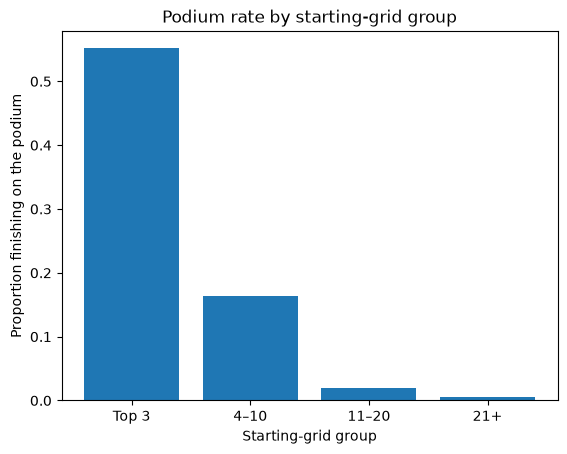

In [ ]:
rate = (
    df_etl_clean
    .dropna(
        subset=["starting_group"]
    )
    .groupby(
        "starting_group",
        observed=False
    )["podium_finish"]
    .mean()
)

print(rate)

plt.bar(
    rate.index.astype(str),
    rate.values
)

plt.xlabel(
    "Starting-grid group"
)

plt.ylabel(
    "Proportion finishing "
    "on the podium"
)

plt.title(
    "Podium rate by "
    "starting-grid group"
)

plt.show()

                  grid  positionOrder  points  laps  fastestLapSpeed  \
grid              1.00           0.45   -0.46 -0.09            -0.12   
positionOrder     0.45           1.00   -0.58 -0.65            -0.16   
points           -0.46          -0.58    1.00  0.25             0.10   
laps             -0.09          -0.65    0.25  1.00            -0.07   
fastestLapSpeed  -0.12          -0.16    0.10 -0.07             1.00   
age_at_race      -0.06          -0.03   -0.02  0.02             0.02   
positions_gained  0.53          -0.53    0.14  0.46             0.05   

                  age_at_race  positions_gained  
grid                    -0.06              0.53  
positionOrder           -0.03             -0.53  
points                  -0.02              0.14  
laps                     0.02              0.46  
fastestLapSpeed          0.02              0.05  
age_at_race              1.00             -0.02  
positions_gained        -0.02              1.00  
Strongest absolute corr

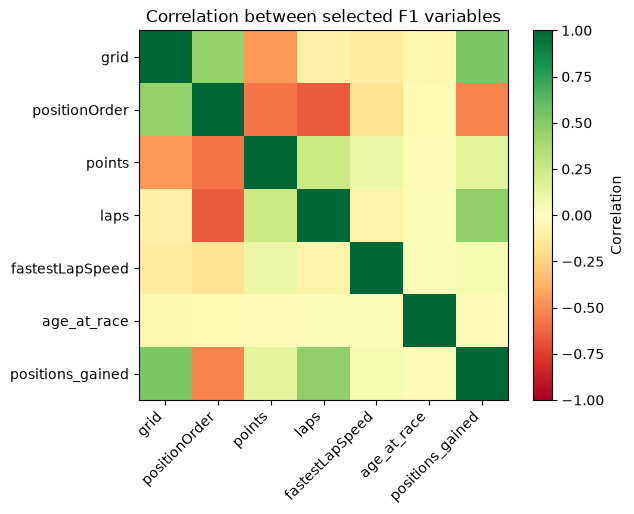

In [ ]:
import numpy as np

num_cols = [
    "grid",
    "positionOrder",
    "points",
    "laps",
    "fastestLapSpeed",
    "age_at_race",
    "positions_gained"
]

corr_matrix = (
    df_etl_clean[
        num_cols
    ].corr()
)

print(
    corr_matrix.round(2)
)

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(
            corr_matrix.shape
        ),
        k=1
    ).astype(bool)
)

strongest_pair = (
    upper_triangle
    .abs()
    .stack()
    .idxmax()
)

print(
    "Strongest absolute correlation:",
    strongest_pair,
    round(
        corr_matrix.loc[
            strongest_pair[0],
            strongest_pair[1]
        ],
        2
    )
)

plt.imshow(
    corr_matrix,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(len(num_cols)),
    num_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(num_cols)),
    num_cols
)

plt.colorbar(
    label="Correlation"
)

plt.title(
    "Correlation between "
    "selected F1 variables"
)

plt.show()

Mean profile per constructor:
              points  grid  positionOrder  fastestLapSpeed  age_at_race
name_team                                                              
McLaren          5.2   8.6            9.2            205.2         27.9
Ferrari          8.6   6.0            6.7            206.8         30.3
Williams         1.6  12.6           12.9            203.9         27.0
Red Bull         9.7   6.6            7.3            206.1         27.9
Mercedes        12.4   5.0            5.9            206.8         32.0
Toro Rosso       0.9  13.8           13.5            199.9         23.1
Renault          2.8  10.2           10.5            204.5         27.6
Sauber           0.9  14.4           13.7            201.5         26.2
Force India      2.6  12.0           11.7            199.7         27.2
Haas F1 Team     0.8  13.6           14.2            207.3         29.1


Text(0.5, 1.0, 'Performance profile by constructor since 2004')

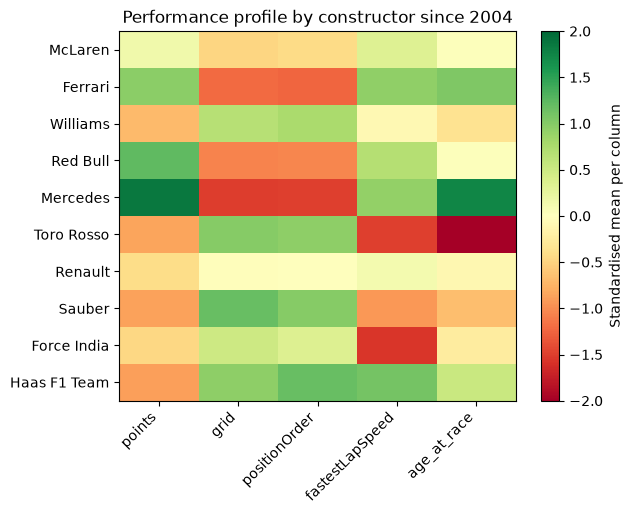

In [ ]:
recent_team_data = (
    df_etl_clean.loc[
        df_etl_clean["year"]
        >= 2004
    ]
)

top_teams = (
    recent_team_data[
        "name_team"
    ]
    .value_counts()
    .head(10)
    .index
)

team_data = recent_team_data.loc[
    recent_team_data[
        "name_team"
    ].isin(top_teams)
]

profile_cols = [
    "points",
    "grid",
    "positionOrder",
    "fastestLapSpeed",
    "age_at_race"
]

profile = (
    team_data
    .groupby(
        "name_team"
    )[profile_cols]
    .mean()
    .loc[top_teams]
)

print(
    "Mean profile per constructor:"
)

print(
    profile.round(1)
)

profile_z = (
    (
        profile
        - profile.mean()
    )
    / profile.std()
)

plt.imshow(
    profile_z.values,
    cmap="RdYlGn",
    vmin=-2,
    vmax=2,
    aspect="auto"
)

plt.xticks(
    range(len(profile_cols)),
    profile_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(profile_z)),
    profile_z.index
)

plt.colorbar(
    label="Standardised mean per column"
)

plt.title(
    "Performance profile by "
    "constructor since 2004"
)

In [ ]:
plt.show()

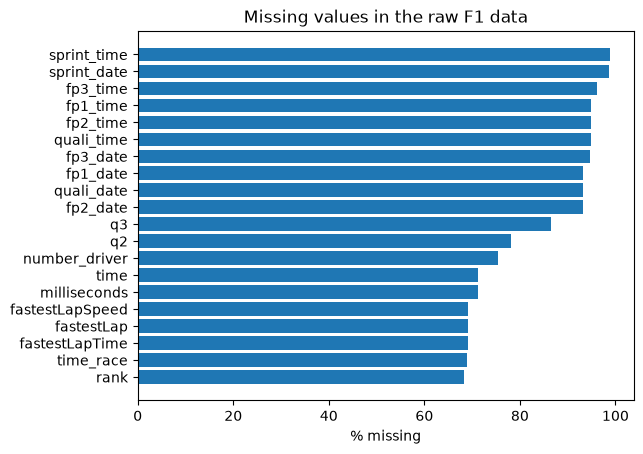

In [ ]:
miss = (
    df_original
    .isna()
    .mean()
    .sort_values(
        ascending=False
    )
)

miss = (
    miss[miss > 0]
    .head(20)
    * 100
)

plt.barh(
    miss.index.astype(str),
    miss.values
)

plt.xlabel("% missing")

plt.title(
    "Missing values in "
    "the raw F1 data"
)

plt.gca().invert_yaxis()

plt.show()

starting_group
Top 3    207.789438
4–10     205.382321
11–20    203.038969
21+      194.121235
Name: fastestLapSpeed, dtype: float64


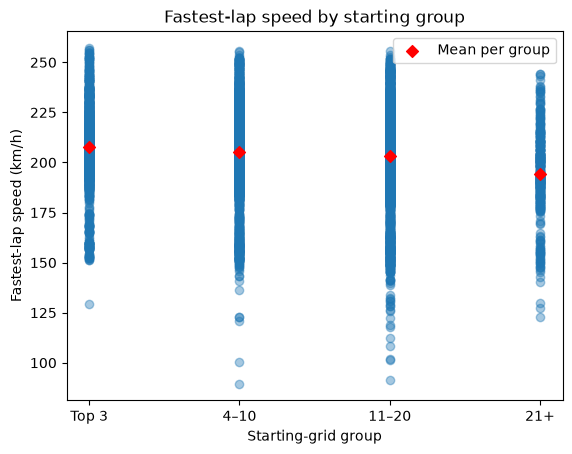

In [ ]:
speed_group_data = (
    df_etl_clean
    .dropna(
        subset=[
            "starting_group",
            "fastestLapSpeed"
        ]
    )
    .copy()
)

group_order = [
    "Top 3",
    "4–10",
    "11–20",
    "21+"
]

x_pos = speed_group_data[
    "starting_group"
].map(
    {
        group: i
        for i, group
        in enumerate(group_order)
    }
)

plt.scatter(
    x_pos,
    speed_group_data[
        "fastestLapSpeed"
    ],
    alpha=0.4
)

means = (
    speed_group_data
    .groupby(
        "starting_group",
        observed=False
    )["fastestLapSpeed"]
    .mean()
)

print(means)

plt.scatter(
    range(len(group_order)),
    [
        means[group]
        for group in group_order
    ],
    color="red",
    marker="D",
    label="Mean per group"
)

plt.xticks(
    range(len(group_order)),
    group_order
)

plt.xlabel(
    "Starting-grid group"
)

plt.ylabel(
    "Fastest-lap speed (km/h)"
)

plt.title(
    "Fastest-lap speed "
    "by starting group"
)

plt.legend()

plt.show()

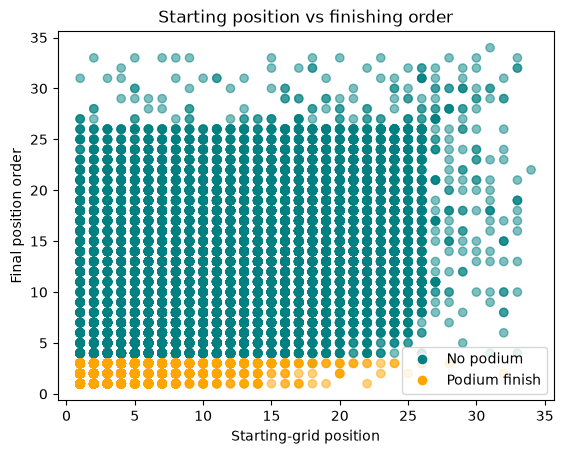

In [ ]:
colors = (
    df_etl_clean[
        "podium_finish"
    ].map(
        {
            True: "orange",
            False: "teal"
        }
    )
)

plt.scatter(
    df_etl_clean["grid"],
    df_etl_clean[
        "positionOrder"
    ],
    c=colors,
    alpha=0.5
)

plt.xlabel(
    "Starting-grid position"
)

plt.ylabel(
    "Final position order"
)

plt.title(
    "Starting position "
    "vs finishing order"
)

from matplotlib.lines import Line2D

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="teal",
        markersize=8,
        label="No podium"
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="orange",
        markersize=8,
        label="Podium finish"
    )
]

plt.legend(
    handles=legend_handles
)

plt.show()

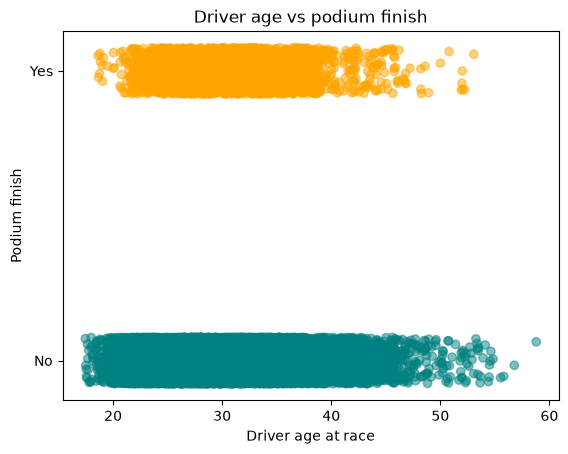

In [ ]:
rng = np.random.default_rng(
    707
)

jitter = (
    df_etl_clean[
        "podium_finish"
    ].astype(int)
    + rng.uniform(
        -0.08,
        0.08,
        len(df_etl_clean)
    )
)

colors = (
    df_etl_clean[
        "podium_finish"
    ].map(
        {
            True: "orange",
            False: "teal"
        }
    )
)

plt.scatter(
    df_etl_clean[
        "age_at_race"
    ],
    jitter,
    c=colors,
    alpha=0.5
)

plt.yticks(
    [0, 1],
    ["No", "Yes"]
)

plt.xlabel(
    "Driver age at race"
)

plt.ylabel(
    "Podium finish"
)

plt.title(
    "Driver age vs podium finish"
)

plt.show()

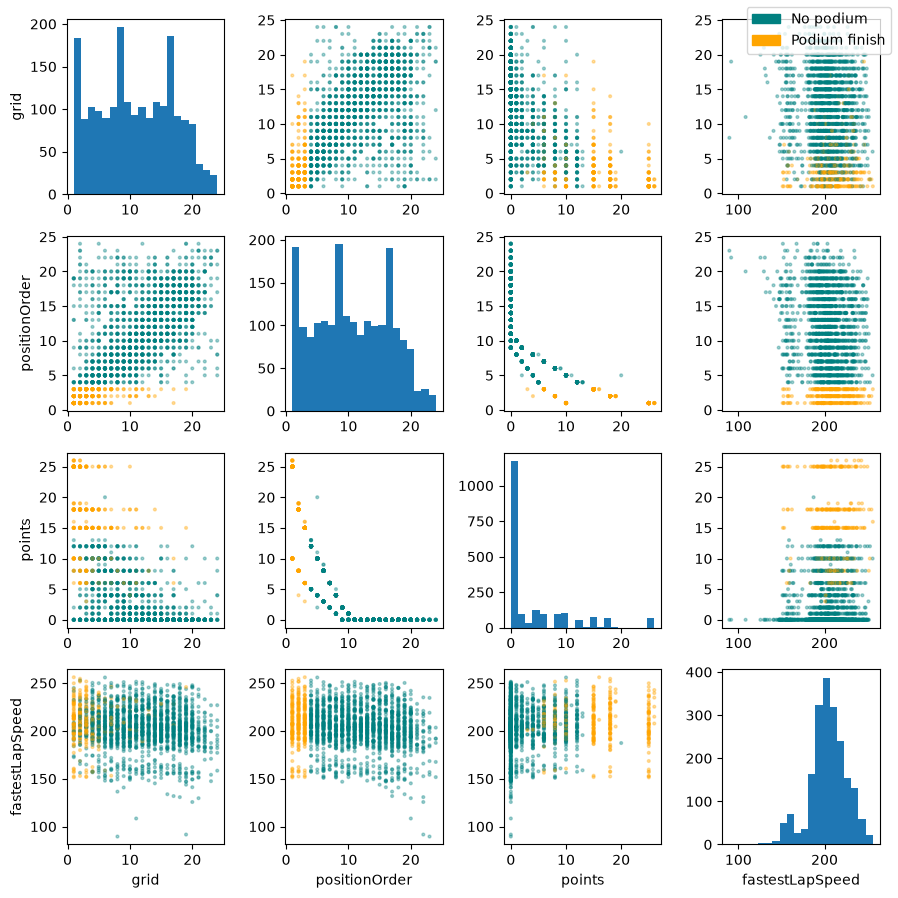

In [ ]:
complete_pair_data = (
    df_etl_clean
    .dropna(
        subset=[
            "grid",
            "positionOrder",
            "points",
            "fastestLapSpeed"
        ]
    )
)

pair_data = (
    complete_pair_data
    .sample(
        n=min(
            2000,
            len(complete_pair_data)
        ),
        random_state=707
    )
)

colors = (
    pair_data[
        "podium_finish"
    ].map(
        {
            True: "orange",
            False: "teal"
        }
    )
)

cols = [
    "grid",
    "positionOrder",
    "points",
    "fastestLapSpeed"
]

fig, axes = plt.subplots(
    4,
    4,
    figsize=(9, 9)
)

for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        ax = axes[i, j]

        if i == j:
            ax.hist(
                pair_data[c1],
                bins=20
            )
        else:
            ax.scatter(
                pair_data[c2],
                pair_data[c1],
                s=4,
                alpha=0.35,
                c=colors
            )

        if i == 3:
            ax.set_xlabel(c2)

        if j == 0:
            ax.set_ylabel(c1)

plt.tight_layout()

from matplotlib.patches import Patch

fig.legend(
    handles=[
        Patch(
            color="teal",
            label="No podium"
        ),
        Patch(
            color="orange",
            label="Podium finish"
        )
    ],
    loc="upper right"
)

plt.show()

In [ ]:
from scipy import stats
a = df_etl_clean.loc[
    df_etl_clean[
        "podium_finish"
    ],
    "fastestLapSpeed"
].dropna()

b = df_etl_clean.loc[
    ~df_etl_clean[
        "podium_finish"
    ],
    "fastestLapSpeed"
].dropna()

t, p = stats.ttest_ind(
    a,
    b,
    equal_var=False
)

print(
    "Mean for podium results:",
    a.mean()
)

print(
    "Mean for non-podium results:",
    b.mean()
)

print(
    f"t = {t:.2f}, p = {p:.4f}"
)

if p < 0.05:
    print(
        "Reject H0: the mean "
        "fastest-lap speeds "
        "differ significantly."
    )
else:
    print(
        "Fail to reject H0: "
        "no significant mean "
        "difference was detected."
    )

Mean for podium results: 208.15411300813008
Mean for non-podium results: 203.40905710623753
t = 7.40, p = 0.0000
Reject H0: the mean fastest-lap speeds differ significantly.


In [ ]:
chi_data = (
    df_etl_clean
    .dropna(
        subset=["grid"]
    )
)

table = pd.crosstab(
    chi_data[
        "top_10_start"
    ],
    chi_data[
        "points_finish"
    ]
)

print(table)

chi2, p, dof, expected = (
    stats.chi2_contingency(
        table
    )
)

print(
    f"chi2 = {chi2:.2f}, "
    f"p = {p:.6f}"
)

if p < 0.05:
    print(
        "Reject H0: top-10 starts "
        "and scoring points are "
        "associated in this sample."
    )
else:
    print(
        "Fail to reject H0: "
        "no significant association "
        "was detected."
    )

points_finish  False  True 
top_10_start               
False          11925   1890
True            5040   6266
chi2 = 4938.86, p = 0.000000
Reject H0: top-10 starts and scoring points are associated in this sample.


# Apex Predictors Phase II

**Student:** Rakesh Kalidindi  
**Student ID:** 24257694  
**Branch:** analysis/p2-rakesh  

## Prediction objective

This project aims to predict whether a Formula 1 driver will finish on the podium. A podium is defined as an official finishing position of first, second or third. Only information available before the race starts will be used as model input to prevent data leakage.

In [2]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
import random
import time
from pathlib import Path

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn import __version__ as sklearn_version
from skeLCS import eLCS

print("Scikit-learn version:", sklearn_version)
print("eLCS imported successfully.")

Scikit-learn version: 1.9.0
eLCS imported successfully.


In [6]:
from skeLCS import eLCS

print("The supplied eLCS implementation imported successfully.")

The supplied eLCS implementation imported successfully.


In [8]:
DATA_PATH = Path("f1_raw_merged_master.csv")

df = pd.read_csv(
    DATA_PATH,
    na_values="\\N",
    low_memory=False
)

df_original = df.copy(deep=True)

print("Raw dataset shape:", df_original.shape)
df_original.head()

FileNotFoundError: [Errno 2] No such file or directory: 'f1_raw_merged_master.csv'

In [ ]:
print("Rows:", len(df_original))
print("Columns:", len(df_original.columns))
print("Races:", df_original["raceId"].nunique())
print("Drivers:", df_original["driverId"].nunique())
print("Constructors:", df_original["constructorId"].nunique())
print("Years:", df_original["year"].min(), "to", df_original["year"].max())
print("Duplicate rows:", df_original.duplicated().sum())
print(
    "Duplicate result IDs:",
    df_original["resultId"].duplicated().sum()
)

In [10]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [11]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

X_example, y_example = make_classification(
    n_samples=200,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    n_classes=2,
    random_state=RANDOM_STATE
)

In [12]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

X_example, y_example = make_classification(
    n_samples=300,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    n_classes=2,
    random_state=RANDOM_STATE
)

X_example_train, X_example_test, y_example_train, y_example_test = (
    train_test_split(
        X_example,
        y_example,
        test_size=0.20,
        stratify=y_example,
        random_state=RANDOM_STATE
    )
)

compatibility_model = eLCS(
    learning_iterations=1000,
    N=500,
    random_state=RANDOM_STATE
)

compatibility_model.fit(
    X_example_train,
    y_example_train
)

compatibility_predictions = compatibility_model.predict(
    X_example_test
)

compatibility_score = balanced_accuracy_score(
    y_example_test,
    compatibility_predictions
)

print("eLCS test completed.")
print("Balanced accuracy:", round(compatibility_score, 4))
print(
    "Final number of rules:",
    len(compatibility_model.population.popSet)
)

eLCS test completed.
Balanced accuracy: 0.75
Final number of rules: 104
